In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

Epoch    0 | Loss: 2661.740967
Epoch  500 | Loss: 1753.199951
Epoch 1000 | Loss: 1199.397949
Epoch 1500 | Loss: 828.041321
Epoch 2000 | Loss: 572.047668
Epoch 2500 | Loss: 393.432892
Epoch 3000 | Loss: 268.446411
Epoch 3500 | Loss: 181.436554
Epoch 4000 | Loss: 121.374763
Epoch 4500 | Loss: 79.960884
Epoch 5000 | Loss: 52.346767
Epoch 5500 | Loss: 34.127007
Epoch 6000 | Loss: 22.251226
Epoch 6500 | Loss: 14.604303
Epoch 7000 | Loss: 10.630873
Epoch 7500 | Loss: 6.567735
Epoch 8000 | Loss: 4.541895
Epoch 8500 | Loss: 3.409985
Epoch 9000 | Loss: 2.378538
Epoch 9500 | Loss: 1.731180
Epoch 10000 | Loss: 1.353733
Epoch 10500 | Loss: 2.452997
Epoch 11000 | Loss: 0.846532
Epoch 11500 | Loss: 0.673559
Epoch 12000 | Loss: 0.567326
Epoch 12500 | Loss: 0.522115
Epoch 13000 | Loss: 0.444696
Epoch 13500 | Loss: 0.395634
Epoch 14000 | Loss: 0.351169
Epoch 14500 | Loss: 0.433062
Epoch 15000 | Loss: 0.303185
Epoch 15500 | Loss: 0.312580
Epoch 16000 | Loss: 3.745710
Epoch 16500 | Loss: 4.182726
Epoch 1

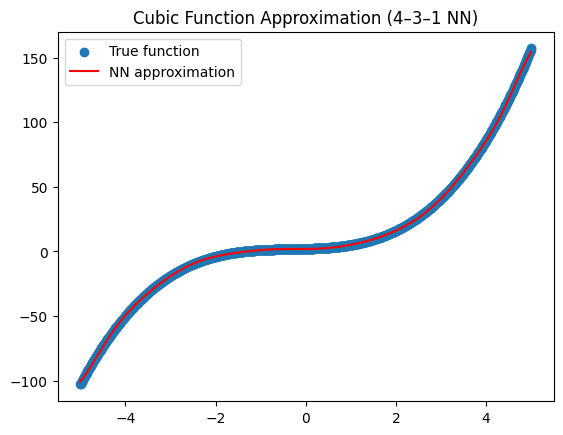

In [10]:
# Generate synthetic data
x = torch.linspace(-5, 5, 1000).unsqueeze(1)  # shape (200, 1)
y = x**3 + x**2 + x + 2

# Construct input features [x, x^2, x^3, 1]
X = torch.cat([x, x**2, x**3, torch.ones_like(x)], dim=1)

# Define network
class PolyNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 3),
            nn.Tanh(),
            nn.Linear(3, 1)
        )

    def forward(self, x):
        return self.net(x)

model = PolyNN()

# Define loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train loop
for epoch in range(25000):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f}")

# Evaluate
with torch.no_grad():
    y_hat = model(X)

# Plot
plt.scatter(x.numpy(), y.numpy(), label="True function")
plt.plot(x.numpy(), y_hat.numpy(), color="red", label="NN approximation")
plt.legend()
plt.title("Cubic Function Approximation (4–3–1 NN)")
plt.show()


In [11]:
# --- Model A: 4 -> 3 ---
class ModelA(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Linear(4, 3)
        self.act = nn.Tanh()
    def forward(self, x):
        return self.act(self.layer(x))

# --- Model B: 3 -> 1 ---
class ModelB(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer = nn.Linear(3, 1)
    def forward(self, x):
        return self.layer(x)

# Initialize both
modelA = ModelA()
modelB = ModelB()

Epoch    0 | Combined Loss: 542.557861
Epoch  200 | Combined Loss: 426.569916
Epoch  400 | Combined Loss: 336.934784
Epoch  600 | Combined Loss: 267.160889
Epoch  800 | Combined Loss: 212.511749
Epoch 1000 | Combined Loss: 169.492813
Epoch 1200 | Combined Loss: 135.502182
Epoch 1400 | Combined Loss: 109.221848
Epoch 1600 | Combined Loss: 87.123497
Epoch 1800 | Combined Loss: 70.128960
Epoch 2000 | Combined Loss: 56.683243
Epoch 2200 | Combined Loss: 45.707714
Epoch 2400 | Combined Loss: 37.071484
Epoch 2600 | Combined Loss: 30.174030
Epoch 2800 | Combined Loss: 24.601072
Epoch 3000 | Combined Loss: 20.173433
Epoch 3200 | Combined Loss: 16.601078
Epoch 3400 | Combined Loss: 13.763608
Epoch 3600 | Combined Loss: 11.411977
Epoch 3800 | Combined Loss: 10.323084
Epoch 4000 | Combined Loss: 8.232224
Epoch 4200 | Combined Loss: 6.762493
Epoch 4400 | Combined Loss: 5.724534
Epoch 4600 | Combined Loss: 4.923038
Epoch 4800 | Combined Loss: 4.185142
Epoch 5000 | Combined Loss: 4.162698
Epoch 5200

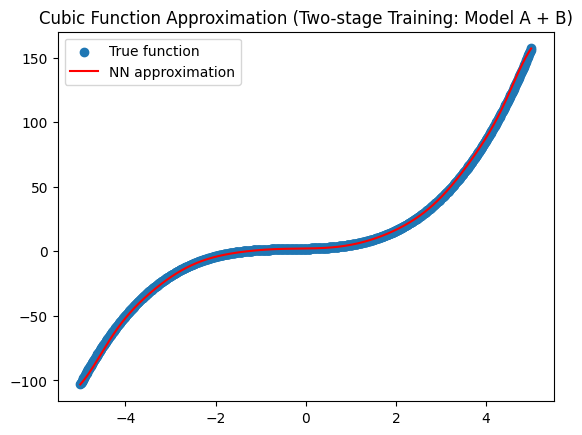

In [13]:
# Optimizers (can share lr or differ)
optA = optim.Adam(modelA.parameters(), lr=0.01)
optB = optim.Adam(modelB.parameters(), lr=0.01)
criterion = nn.MSELoss()

# --- Training loop ---
for epoch in range(25000):
    # Forward pass
    h = modelA(X)
    y_pred = modelB(h)
    loss = criterion(y_pred, y)

    # Backward pass
    optA.zero_grad()
    optB.zero_grad()
    loss.backward()
    
    # Update sequentially
    optB.step()  # update last layer first
    optA.step()  # then update first layer

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Combined Loss: {loss.item():.6f}")

# --- Evaluate ---
with torch.no_grad():
    y_hat = modelB(modelA(X))

plt.scatter(x.numpy(), y.numpy(), label="True function")
plt.plot(x.numpy(), y_hat.numpy(), color="red", label="NN approximation")
plt.legend()
plt.title("Cubic Function Approximation (Two-stage Training: Model A + B)")
plt.show()